In [7]:
try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gymnasium', '-q'])
    import gymnasium as gym

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

env = gym.make('FrozenLake-v1', is_slippery=True)
n_s = env.observation_space.n
n_a = env.action_space.n
random_policy = lambda s: env.action_space.sample()

true_V = np.array([0, 1/6, 2/6, 3/6, 4/6, 5/6, 0])

class RandomWalkEnv:
    def reset(self):
        self.s = 3
        return self.s
    def step(self, a=None):
        self.s += np.random.choice([-1, 1])
        done = self.s in [0, 6]
        r = 1.0 if self.s == 6 else 0.0
        return self.s, r, done


--- EXERCISE 1 OUTPUT ---


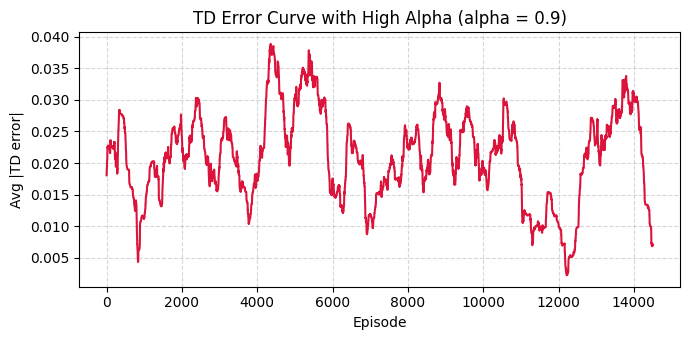

In [8]:
 #Exercises -1-Increase α to 0.9. What happens to the TD error curve? Does it still converge?
def td0_prediction_frozen_lake(env, policy_fn, n_episodes=15_000, alpha=0.9, gamma=0.99):
    V = np.zeros(n_s)
    td_errors_per_ep = []
    for _ in range(n_episodes):
        s, _ = env.reset()
        ep_errors = []
        done = False
        while not done:
            a = policy_fn(s)
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc
            td_target = r + gamma * V[ns] * (not done)
            td_error = td_target - V[s]
            V[s] += alpha * td_error
            ep_errors.append(abs(td_error))
            s = ns
        td_errors_per_ep.append(np.mean(ep_errors))
    return V, td_errors_per_ep

V_td_high, td_errors_high = td0_prediction_frozen_lake(env, random_policy)
window = 500
rolling_err_high = np.convolve(td_errors_high, np.ones(window)/window, mode='valid')

print("--- EXERCISE 1 OUTPUT ---")
plt.figure(figsize=(7, 3.5))
plt.plot(rolling_err_high, color='crimson', linewidth=1.5)
plt.xlabel('Episode')
plt.ylabel('Avg |TD error|')
plt.title('TD Error Curve with High Alpha (alpha = 0.9)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



--- EXERCISE 2 OUTPUT ---


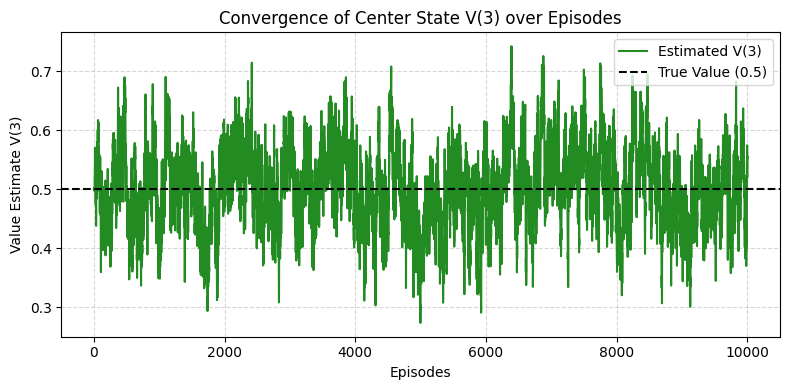

Value Estimate of V(3) at 1000 episodes: 0.4390
Value Estimate of V(3) at 5000 episodes: 0.3853
Value Estimate of V(3) at 10000 episodes: 0.5535


In [9]:
#2-Run TD(0) for 1000, 5000, and 10000 episodes. Plot how the estimate of V(3) (centre state) converges to 0.5.
def track_v3_convergence(episodes_list=[1000, 5000, 10000], alpha=0.1, gamma=1.0):
    max_episodes = max(episodes_list)
    V = np.full(7, 0.5)
    V[0] = V[6] = 0.0
    v3_history = []
    episodes_axis = []

    for ep in range(1, max_episodes + 1):
        env_rw = RandomWalkEnv()
        s = env_rw.reset()
        done = False
        while not done:
            ns, r, done = env_rw.step()
            V[s] += alpha * (r + gamma * V[ns] - V[s])
            s = ns

        v3_history.append(V[3])
        episodes_axis.append(ep)

    return episodes_axis, v3_history, episodes_list

episodes_axis, v3_history, targets = track_v3_convergence()

print("\n--- EXERCISE 2 OUTPUT ---")
plt.figure(figsize=(8, 4))
plt.plot(episodes_axis, v3_history, color='forestgreen', linewidth=1.5, label='Estimated V(3)')
plt.axhline(y=0.5, color='black', linestyle='--', linewidth=1.5, label='True Value (0.5)')
plt.xlabel('Episodes')
plt.ylabel('Value Estimate V(3)')
plt.title('Convergence of Center State V(3) over Episodes')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

for target in targets:
    print(f"Value Estimate of V(3) at {target} episodes: {v3_history[target-1]:.4f}")


In [10]:
#Challenge: implement TD(λ) with eligibility traces. Does λ=0 reproduce TD(0) and λ=1 approximate MC?
def td_lambda_prediction_rw(n_episodes=300, alpha=0.1, lmbda=0.5, gamma=1.0):
    V = np.full(7, 0.5)
    V[0] = V[6] = 0.0
    for _ in range(n_episodes):
        env_rw = RandomWalkEnv()
        s = env_rw.reset()
        E = np.zeros(7)
        done = False
        while not done:
            ns, r, done = env_rw.step()
            td_error = r + gamma * V[ns] - V[s]
            E[s] += 1.0

            for state in range(1, 6):
                V[state] += alpha * td_error * E[state]
                E[state] = gamma * lmbda * E[state]
            s = ns
    return V

V_lambda_0 = td_lambda_prediction_rw(lmbda=0.0)
V_lambda_1 = td_lambda_prediction_rw(lmbda=1.0)

print("\n--- EXERCISE 3 OUTPUT ---")
print("True V:      ", true_V[1:6])
print("TD(lambda=0):", np.round(V_lambda_0[1:6], 4))
print("TD(lambda=1):", np.round(V_lambda_1[1:6], 4))

rms_0 = np.sqrt(np.mean((V_lambda_0[1:6] - true_V[1:6])**2))
rms_1 = np.sqrt(np.mean((V_lambda_1[1:6] - true_V[1:6])**2))
print(f"RMS Error for lambda=0 (Replicates TD(0)): {rms_0:.4f}")
print(f"RMS Error for lambda=1 (Approximates MC):  {rms_1:.4f}")



--- EXERCISE 3 OUTPUT ---
True V:       [0.16666667 0.33333333 0.5        0.66666667 0.83333333]
TD(lambda=0): [0.1873 0.3691 0.586  0.7381 0.949 ]
TD(lambda=1): [0.0898 0.0967 0.1452 0.3429 0.6388]
RMS Error for lambda=0 (Replicates TD(0)): 0.0743
RMS Error for lambda=1 (Approximates MC):  0.2571
